## Example: Phase space flow and Liouville's theorem in a double-well potential

In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Polygon
from scipy.integrate import solve_ivp
from IPython.display import HTML

In order to illustrate the concept of phase space flow and Liouville's theorem, we will consider a simple classical system: a particle moving in a double-well potential. The double-well potential can be described by the following potential energy function:

$$ 
V(q) = a(q^2 - b^2)^2 
$$

In the example below we choose $a=1$ and $b=1$ for simplicity, which gives us the potential:

$$
V(q) = (q^2 - 1)^2

$$

where $a$ and $b$ are positive constants that determine the shape of the potential. In the following we plot the potential and the corresponding phase space curves for different energy levels including the separatrix that separates two different types of motion: perisodic motion around each well and oscillatory motion that crosses the barrier between the wells. 

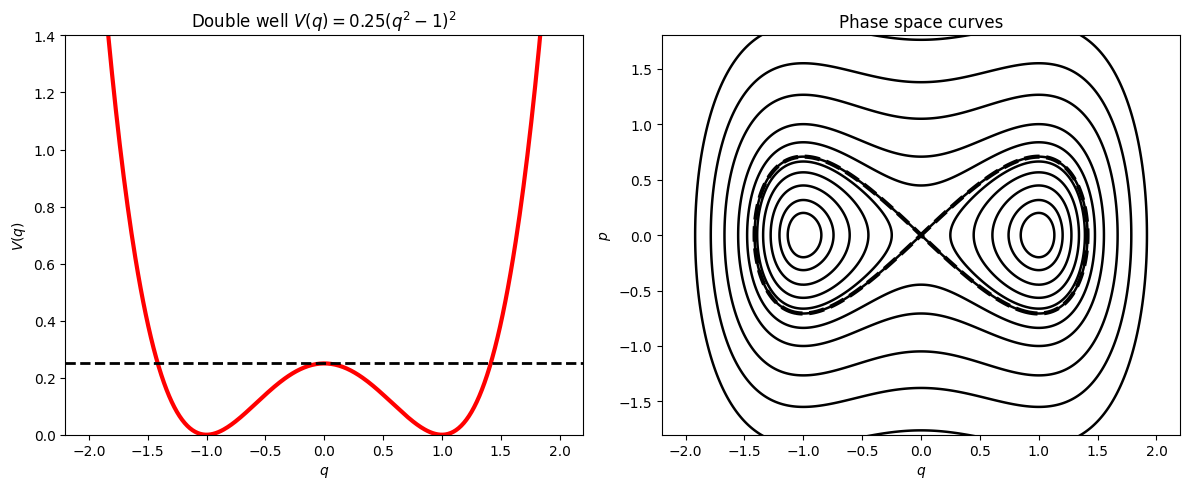

In [12]:
q = np.linspace(-2.2, 2.2, 400)

def V(q):
    return 0.25 * (q**2 - 1)**2

pot = V(q)
E_sep = 0.25

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(q, pot, color="red", lw=3.0)
ax[0].axhline(E_sep, color="black", ls="--", lw=2)
ax[0].set_xlabel("$q$")
ax[0].set_ylabel("$V(q)$")
ax[0].set_title("Double well $V(q)=0.25(q^2 - 1)^2$")
ax[0].set_xlim(-2.2, 2.2)
ax[0].set_ylim(0, 1.4)

Q, P = np.meshgrid(np.linspace(-2.2, 2.2, 400), np.linspace(-2.2, 2.2, 400))
H = 0.5 * P**2 + 0.25 * (Q**2 - 1)**2

levels = [0.02, 0.05, 0.10, 0.16, 0.22, E_sep, 0.35, 0.5, 0.8, 1.2, 1.8]
ax[1].contour(Q, P, H, levels=levels, colors="black", linewidths=1.8)
ax[1].contour(Q, P, H, levels=[E_sep], colors="black", linewidths=3.0, linestyles="--")
ax[1].set_xlabel("$q$")
ax[1].set_ylabel("$p$")
ax[1].set_title("Phase space curves")
ax[1].set_xlim(-2.2, 2.2)
ax[1].set_ylim(-1.8, 1.8)

plt.tight_layout()
plt.show()

The Hamiltonian of the system can be written as:

$$
H(q, p) = \frac{p^2}{2m} + V(q) = \frac{p^2}{2m} + 0.25(q^2 - 1)^2
$$

From this we can derive the equations of motion using Hamilton's equations:

$$
\dot{q} = \frac{\partial H}{\partial p} = \frac{p}{m}
$$

$$
\dot{p} = -\frac{\partial H}{\partial q} = -q(q^2 - 1)
$$

We not propagate the system starting with a region in the phase space that has an elliptical shape and observe how it evolves over time. According to Liouville's theorem, the area of this region in phase space should remain constant as it evolves, even though its shape may change. We will visualize this by plotting the phase space trajectories and the evolving region in phase space at different time steps. 

The initial conditions are generated by sampling points from an elliptical region in phase space defined by:  

$$
p = p_0 + b \sin(\theta) 
$$

$$ 
q = q_0 + a \cos(\theta) 
$$

where $a$ and $b$ are the semi-major and semi-minor axes of the ellipse, respectively, and $\theta$ is a parameter that ranges from 0 to $2\pi$. We will choose $a=0.5$, $b=0.5$, and center the ellipse at $(q_0, p_0) = (0, 0)$ for our initial conditions. The boundary of the ellipse is then propagated by numerically solving the equations of motion numerically. 

    

In [ ]:
mpl.rcParams["animation.embed_limit"] = 100

def rhs(t, y):
    n = y.size // 2
    q = y[:n]
    p = y[n:]
    return np.concatenate([p, q - q**3])

n = 2000
tmax = 40
frames = 250
q0, p0 = -1., 1.5
a = 0.3
b = 0.3
theta = np.linspace(0, 2*np.pi, n, endpoint=False)
y0 = np.concatenate([q0 + a*np.cos(theta), p0 + b*np.sin(theta)])

t_eval = np.linspace(0, tmax, frames)
sol = solve_ivp(rhs, (0, tmax), y0, t_eval=t_eval, method="DOP853", rtol=1e-10, atol=1e-12)

q = sol.y[:n]
p = sol.y[n:]

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.set_title("Double-well phase-space flow")

Q, P = np.meshgrid(np.linspace(-2.2, 2.2, 200), np.linspace(-2.2, 2.2, 200))
H = 0.5 * P**2 + 0.25 * (Q**2 - 1)**2
ax.contour(Q, P, H, levels=np.linspace(0.05, 2.2, 10), colors="0.0", linewidths=2)

poly = Polygon(
    np.column_stack([q[:, 0], p[:, 0]]),
    closed=True,
    facecolor="red",
    edgecolor="red",
    alpha=0.5,
    joinstyle="round",

    linewidth=3,
)


ax.add_patch(poly)
time_text = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top")

def update(i):
    poly.set_xy(np.column_stack([q[:, i], p[:, i]]))
    time_text.set_text(f"t = {t_eval[i]:.2f}")
    return poly, time_text

ani = FuncAnimation(fig, update, frames=frames, interval=40, blit=True)
plt.close(fig)

HTML(ani.to_jshtml())

### Animation illustrating the Liouville's theorem 

<video controls preload="metadata" width="50%" style="max-width: 900px;">
  <source src="_static/figures/animations/double_well_liouville.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>
